<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs

##Soft SVM
**Training Data** <br>
Linearly separable data with binary classification (only this is covered in the syllabus)<br>
Features - (n,m) - No dummy features, No transformation<br>
Labels - (n,) - Classified as -1 and 1

**Model**<br>
$y = sign(w^Tx + b)$

**Decision Boundary**<br>
$w^Tx + b = 0$

**Bounding Planes with slack**<br>
$y^{(i)}(w^Tx^{(i)}+b) >= 1 - \xi ^{(i)} where \xi ^{(i)} > 0$

**Objective Function**<br>
For $C \neq 0 $ objective is to minimise $\xi ^{(i)}$ as much as possible, which is possible with $y^{(i)}(w^T x^{(i)} + b)$

In order to prevent the slack variable becoming too large we penalize it in the objective function

$min_{w,b} \frac {1}{2} ||w||^2 + C \sum \xi ^ {(i)}$ <br>
such that $y^{(i)}(w^T x^{(i)} + b) >= 1 - \xi ^{(i)} \forall \xi^{(i)} >= 0$


\begin{align}
        \xi ^{(i)} = \left\{
        \begin{array}{cl}
        1-y^{(i)}(w^T x^{(i)} + b) & {if } y^{(i)}(w^T x^{(i)} + b) < 1) \\
        0 & {if } y^{(i)}(w^T x^{(i)} + b) \ge 1).
        \end{array}
        \right.
    \end{align}

This is equivalent to
$\xi ^{(i)} = max(1-y^{(i)}(w^T x^{(i)} + b),0)$

**Objective** is
$min_{w,b} \frac{1}{2} ||w||^2 + C \sum max(1-y^{(i)}(w^T x^{(i)} + b),0)$<br>

The second part is called the **hinge loss**

Taking partial derivative<br>

\begin{align}
        \frac {\partial} {\partial w} max(1-y^{(i)}(w^T x^{(i)} + b),0) = \left\{
        \begin{array}{cl}
        0 & {if} 1-y^{(i)}(w^T x^{(i)} + b) = 0 \\
        y^{(i)}x^{(i)} & otherwise.
        \end{array}
        \right.
    \end{align}

\begin{align}
        \frac {\partial } {\partial b} max(1-y^{(i)}(w^T x^{(i)} + b),0) = \left\{
        \begin{array}{cl}
        0 & {if} 1-y^{(i)}(w^T x^{(i)} + b) = 0 \\
        y^{(i)} & otherwise.
        \end{array}
        \right.
    \end{align}

Writing compactly <br>
$\frac {\partial}{\partial w} J(w,b) = w - C \sum 1(1-y^{(i)}(w^T x^{(i)} + b) > 0)y^{(i)} x^{(i)}$ <br>

$\frac {\partial}{\partial b} J(w,b) = C \sum 1(1-y^{(i)}(w^T x^{(i)} + b) > 0)y^{(i)}$


**Gradient Update Rule** <br>
$w_{new} = w_{old} - lr * \frac {\partial}{\partial w} J(w,b)$ <br>
$b_{new} = b_{old} - lr * \frac {\partial}{\partial b} J(w,b)$

In [ ]:
def decision(x,w,b):
  return x@w + b

def predict(x,w,b):
  return np.sign(decision(x,w,b))

def margin(x,w,b,y):
  return y*decision(x,w,b)

def cost(x,w,b,y,C):
  return 0.5*(w.T @ w) + C*np.sum(np.maximum(1-margin(x,w,b,y),0))

def fit(x,y,C, epochs, lr):
  #initialise w and b
  w = np.zeros(X.shape[1])
  b = 0
  w_all = []
  cost_all = []

  #train
  for i in range(epochs):
    mrgn = margin(x,w,b,y)
    cost_all.append(cost(x,w,b,y,C))

    #Identify indices where y(Xw+b) < 1
    misclassified_pts_idx = np.where(mrgn < 1)[0]
    gradw = w - C*np.sum(y[misclassified_pts_idx]@x[misclassified_pts_idx])
    gradb = C*np.sum(y[misclassified_pts_idx])
    w = w - lr * gradw
    b = b - lr * gradb

  support_vectors = np.where(margin(x,w,b,y) <=1)[0]

  return w,b,support_vectors

def score(x,w,b,y):
  P = predict(x,w,b)
  return np.mean(y == P)




In [ ]:
X = np.array([[3,1],[3,-1],[6,1],[6,-1],[1,0],[0,1],[0,-1],[-1,0]])
Y = np.array([1,1,1,1,-1,-1,-1,-1])


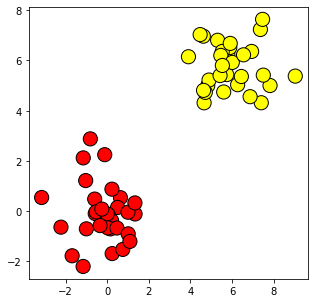

In [ ]:
#Generate Data set
X, Y = make_blobs(n_samples = 60, n_features = 2, centers = [[0,0],[6,6]], cluster_std = 1, random_state = 12)
Y = np.where(Y == 0, -1, 1)

# Plot
plt.figure(figsize = (5,5))
plt.scatter(X[:, 0], X[:, 1], marker='o',c=Y,s=200,edgecolor = 'k',cmap = 'autumn')


In [ ]:
w,b,supp = fit(X,Y,1,100,0.1)
w,b

(array([3.92773498e-05, 3.92773498e-05]), 39.199999999999925)

In [ ]:
P = predict(X,w,b)
P[:5], Y[:5]


(array([1., 1., 1., 1., 1.]), array([-1,  1, -1,  1, -1]))

$y(w^Tx+b) = 1$
$(w^Tx+b) = y^{-1}$

assuming b is included as dummy in w <br>
$w^Tx = y^{-1}$

$w^T = y^{-1}x^{-1}$<br>
$w^T = (xy)^{-1}$<br>
$w = ((xy)^{-1})^T$



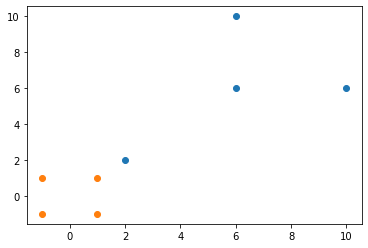

In [ ]:
x1 = np.array([[2,2],[10,6],[6,10],[6,6]])
x2 = np.array([[1,1],[1,-1],[-1,1],[-1,-1]])
#x_1 = np.where(np.sqrt(x1[:,0]**2+x1[:,1]) > 2, np.array([4-x1[:,1]+np.abs(x1[:,0]-x1[:,1])],[4-x1[:,0]+np.abs(x1[:,0]-x1[:,1])]),x1)
#print(x_1)
plt.scatter(x1[:, 0],x1[:, 1])
plt.scatter(x2[:, 0],x2[:, 1])


In [ ]:
def decision(X,w,b):
  return X@w + b

def margin(X,w,b,y):
  return y*decision(X,w,b)

def loss(X,w,b,y):
  return 0.5*(w.T@w) + C*np.sum(np.maximum(0,1-margin(X,w,b,y)))

def fit(X,y, C, lr, epochs):
  #initialise
  w = np.zeros(X.shape[1])
  b = 0

  for i in range(epochs):
    mrgn = margin(X,w,b,y)

    misclassified_idx = np.where(mrgn < 1)[0]
    grad_w = w - C*np.sum(y[misclassified_idx] * X[misclassified_idx])
    grad_b = C*np.sum(y[misclassified_idx])
    w = w - lr*grad_w
    b = b - lr*grad_b

  support_vectors = np.where(margin(X,w,b,y) <= 1)[0]
  return w,b,support_vectors

